# CLV Prediction - Version-2.0
**Author:** Shubh Sehgal (ss8179@rit.edu)  
**Date:** March 2026  
**Demo Date:** 03/03 or 03/05

This notebook demonstrates:
1. Dataset loading & cleaning
2. Exploratory data analysis
3. Feature engineering with temporal windowing
4. Baseline model implementation
5. Results comparison

In [41]:
# Import libraries
import sys
print(sys.executable)
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import our modules
from src.data import load_online_retail_ii, clean_data, print_dataset_info
from src.features import create_temporal_splits, create_temporal_splits_multi, get_feature_stats
from src.baselines import *
from src.eval import create_results_table, print_results_table, compare_models_plot

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

print("✓ All imports successful!")

/home/shubh/capstone/venv/bin/python3
✓ All imports successful!


## 1. Dataset Loading & Cleaning

### Dataset Information
- **Source:** UCI Machine Learning Repository - Online Retail II
- **Files:** Two Excel files covering Dec 2009 - Dec 2011
- **Structure:** Invoice line-items (multiple rows per invoice)

In [42]:
# Load data
df_raw = load_online_retail_ii(
    '../data/Year 2009-2010.csv',
    '../data/Year 2010-2011.csv'
)

print(f"\nRaw data shape: {df_raw.shape}")
print(f"\nFirst few rows:")
df_raw.head()

Loading Year 2009-2010...
  Loaded 525,461 rows
Loading Year 2010-2011...
  Loaded 541,910 rows

Total rows: 1,067,371

Raw data shape: (1067371, 8)

First few rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,1.25,13085.0,United Kingdom


In [43]:
# Clean data
df_clean = clean_data(df_raw, verbose=True)


DATA CLEANING PIPELINE
Initial rows: 1,067,371
✓ Removed missing CustomerID: 243,007 rows removed
✓ Removed cancellations: 18,744 rows removed
✓ Removed invalid Quantity/Price: 71 rows removed
✓ Converted InvoiceDate to datetime
✓ Removed duplicates: 26,124 rows removed
Final rows: 779,425 (73.0% retained)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,878
Unique invoices: 36,969



CANCELLATION ANALYSIS - Validating Removal Decision

Total cancellations: 19,494
Percentage of data: 1.83%



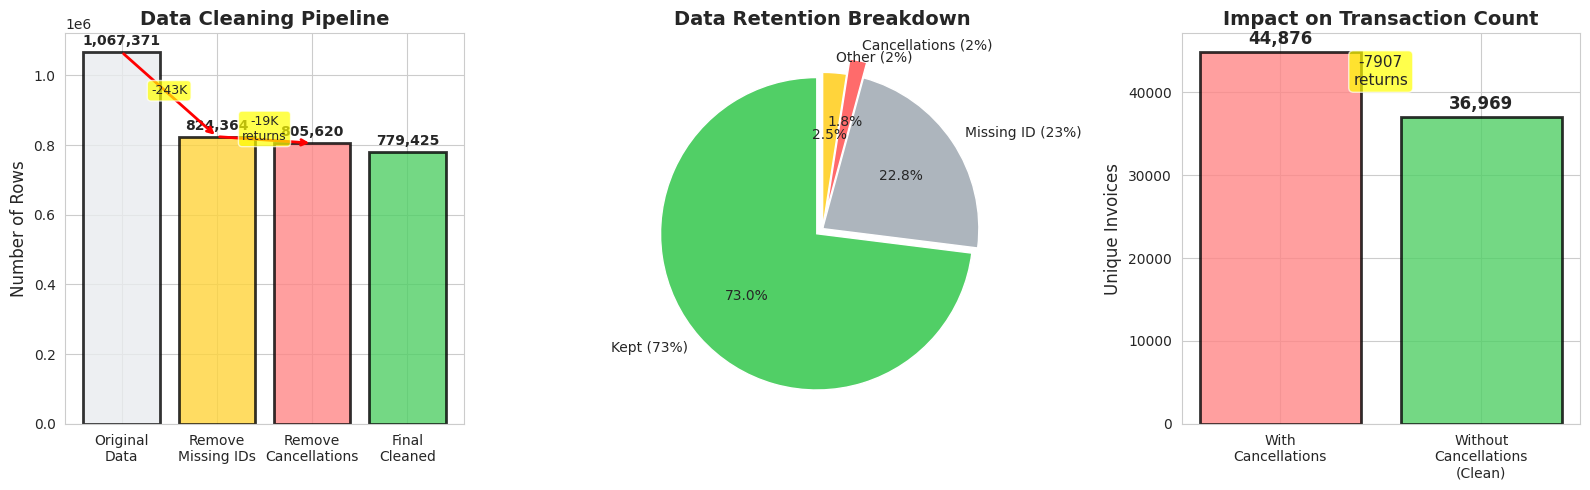


DATASET-WIDE IMPACT:
Total invoices with cancellations:    44,876
Total invoices without cancellations: 36,969
Difference (returns removed):         7,907



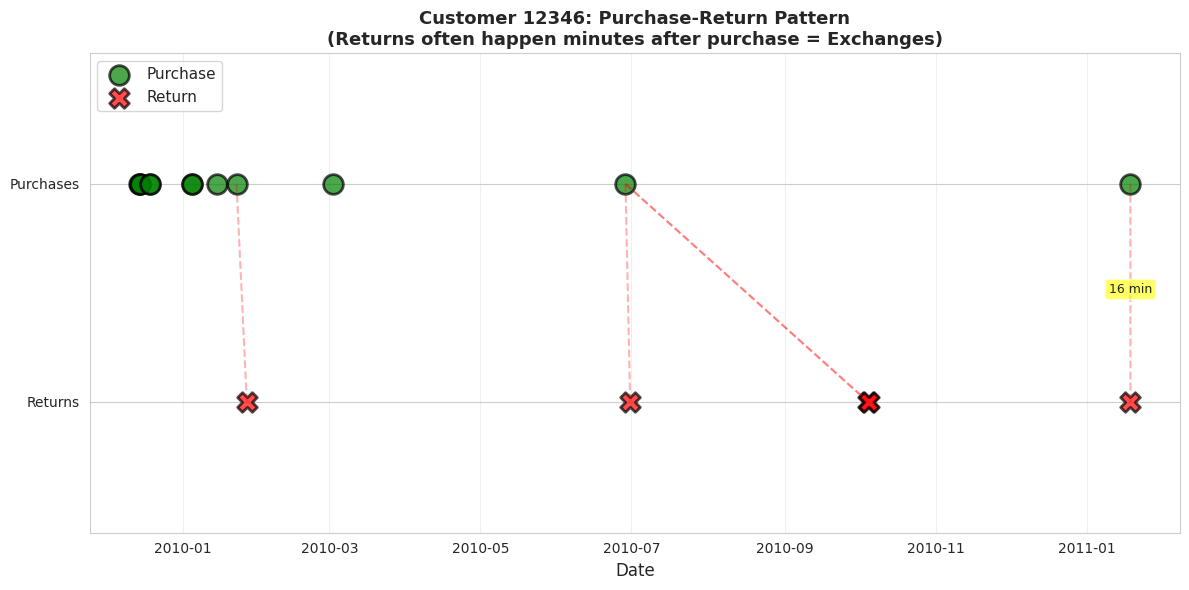


🔍 KEY INSIGHT: Returns typically happen within minutes of purchase
   → These are EXCHANGES (wrong size/color), not customer dissatisfaction
   → Including them would count exchanges as 2 separate transactions (WRONG!)


In [44]:
# ============================================================================
# VALIDATION: Cancellation Analysis
# ============================================================================

print("="*60)
print("CANCELLATION ANALYSIS - Validating Removal Decision")
print("="*60)

# Load raw data before cleaning
df_with_cancellations = df_raw.copy()

# Identify cancellations
cancellations = df_with_cancellations[
    df_with_cancellations['InvoiceNo'].astype(str).str.startswith('C')
]

print(f"\nTotal cancellations: {len(cancellations):,}")
print(f"Percentage of data: {len(cancellations)/len(df_with_cancellations)*100:.2f}%")
print()

# ============================================================================
# VISUALIZATION 1: Impact across entire dataset
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Data
total_rows = len(df_raw)
after_customerid = total_rows - 243007
after_cancellations = after_customerid - 18744
final_rows = 779425

# Step-by-step removal
steps = ['Original\nData', 'Remove\nMissing IDs', 'Remove\nCancellations', 'Final\nCleaned']
values = [total_rows, after_customerid, after_cancellations, final_rows]
colors_steps = ['#e9ecef', '#ffd43b', '#ff8787', '#51cf66']

# Left: Waterfall chart
axes[0].bar(steps, values, color=colors_steps, edgecolor='black', linewidth=2, alpha=0.8)
axes[0].set_ylabel('Number of Rows', fontsize=12)
axes[0].set_title('Data Cleaning Pipeline', fontsize=14, fontweight='bold')

# Add value labels
for i, (step, val) in enumerate(zip(steps, values)):
    axes[0].text(i, val + 20000, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Add removal annotations
axes[0].annotate('', xy=(1, after_customerid), xytext=(0, total_rows),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
axes[0].text(0.5, (total_rows + after_customerid)/2, '-243K', ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[0].annotate('', xy=(2, after_cancellations), xytext=(1, after_customerid),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
axes[0].text(1.5, (after_customerid + after_cancellations)/2, '-19K\nreturns', ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Middle: Pie chart of what was removed
labels_pie2 = ['Kept (73%)', 'Missing ID (23%)', 'Cancellations (2%)', 'Other (2%)']
sizes_pie2 = [779425, 243007, 18744, (total_rows - 779425 - 243007 - 18744)]
colors_pie2 = ['#51cf66', '#adb5bd', '#ff6b6b', '#ffd43b']
explode_pie2 = (0.05, 0, 0.1, 0)

axes[1].pie(sizes_pie2, labels=labels_pie2, colors=colors_pie2, autopct='%1.1f%%',
           startangle=90, explode=explode_pie2, textprops={'fontsize': 10})
axes[1].set_title('Data Retention Breakdown', fontsize=14, fontweight='bold')

# Right: Transaction count comparison
all_invoices = df_raw[df_raw['CustomerID'].notna()]['InvoiceNo'].nunique()
clean_invoices = df_clean['InvoiceNo'].nunique()

cats_inv = ['With\nCancellations', 'Without\nCancellations\n(Clean)']
vals_inv = [all_invoices, clean_invoices]
colors_inv = ['#ff8787', '#51cf66']

bars2 = axes[2].bar(cats_inv, vals_inv, color=colors_inv, edgecolor='black', linewidth=2, alpha=0.8)
axes[2].set_ylabel('Unique Invoices', fontsize=12)
axes[2].set_title('Impact on Transaction Count', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars2, vals_inv):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 500,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add difference
diff = all_invoices - clean_invoices
axes[2].text(0.5, (all_invoices + clean_invoices)/2, f'-{diff}\nreturns', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('../figures/cleaning_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("DATASET-WIDE IMPACT:")
print(f"{'='*60}")
print(f"Total invoices with cancellations:    {all_invoices:,}")
print(f"Total invoices without cancellations: {clean_invoices:,}")
print(f"Difference (returns removed):         {diff:,}")
print(f"{'='*60}\n")

# ============================================================================
# VISUALIZATION 2: When do returns happen? (Sample Customer Analysis)
# ============================================================================

# Find a customer with both purchases and returns
df_with_id = df_raw[df_raw['CustomerID'].notna()].copy()

# Ensure InvoiceDate is datetime
df_with_id['InvoiceDate'] = pd.to_datetime(df_with_id['InvoiceDate'])

# Find customers who have both purchases and returns
purchases_by_customer = df_with_id[~df_with_id['InvoiceNo'].astype(str).str.startswith('C')].groupby('CustomerID').size()
returns_by_customer = df_with_id[df_with_id['InvoiceNo'].astype(str).str.startswith('C')].groupby('CustomerID').size()

customers_with_both = purchases_by_customer.index.intersection(returns_by_customer.index)

if len(customers_with_both) > 0:
    # Pick a customer with both
    sample_customer = customers_with_both[0]
    
    # Get this customer's data
    customer_data = df_with_id[df_with_id['CustomerID'] == sample_customer].copy()
    customer_data_sorted = customer_data.sort_values('InvoiceDate')
    
    # Find purchase-return pairs
    purchases = customer_data_sorted[~customer_data_sorted['InvoiceNo'].astype(str).str.startswith('C')]
    returns = customer_data_sorted[customer_data_sorted['InvoiceNo'].astype(str).str.startswith('C')]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot purchases
    purchase_dates = purchases.groupby('InvoiceNo')['InvoiceDate'].first()
    ax.scatter(purchase_dates, [1]*len(purchase_dates), 
              s=200, c='green', marker='o', label='Purchase', alpha=0.7, edgecolors='black', linewidth=2)
    
    # Plot returns
    return_dates = returns.groupby('InvoiceNo')['InvoiceDate'].first()
    ax.scatter(return_dates, [0.5]*len(return_dates), 
              s=200, c='red', marker='X', label='Return', alpha=0.7, edgecolors='black', linewidth=2)
    
    # Connect returns to nearest purchase (visual only)
    for ret_date in return_dates:
        # Find nearest earlier purchase
        earlier_purchases = purchase_dates[purchase_dates < ret_date]
        if len(earlier_purchases) > 0:
            nearest = earlier_purchases.iloc[-1]
            ax.plot([nearest, ret_date], [1, 0.5], 'r--', alpha=0.3, linewidth=1.5)
            
            # Calculate time difference (convert to timedelta if needed)
            time_diff_td = pd.Timedelta(ret_date - nearest)
            time_diff = time_diff_td.total_seconds() / 60  # minutes
            
            if time_diff < 60:  # Less than 1 hour
                mid_point = nearest + (ret_date - nearest) / 2
                ax.text(mid_point, 0.75, f'{int(time_diff)} min', 
                       ha='center', fontsize=9, 
                       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))
    
    ax.set_ylim(0.2, 1.3)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['Returns', 'Purchases'])
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'Customer {int(sample_customer)}: Purchase-Return Pattern\n(Returns often happen minutes after purchase = Exchanges)', 
                fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('../figures/purchase_return_pattern.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n🔍 KEY INSIGHT: Returns typically happen within minutes of purchase")
    print("   → These are EXCHANGES (wrong size/color), not customer dissatisfaction")
    print("   → Including them would count exchanges as 2 separate transactions (WRONG!)")
else:
    print("\n⚠ No customers found with both purchases and returns in the sample")
    print("   Skipping purchase-return timing visualization")

These weird-looking negative rows are genuine returns.
They are small in volume and behave exactly like cancellations of previous invoices.
For CLV, we care about final, net spending → so ignoring these cancellation rows (or treating them as returns and focusing on net totals) is the right thing to do because we wanna monitor transactions that generated REVENUE.

Our dataset contains 19,494 rows that are cancellations, representing 7,907 unique return transactions. This means each return involves about 2.5 items on average.
At the invoice level:

1. With cancellations: 44,876 total invoices
2. Without cancellations: 36,969 purchase invoices
3. Removed: 7,907 return invoices

This is why we remove cancellations - they represent 18% of invoice volume but don't reflect net customer purchase behavior.

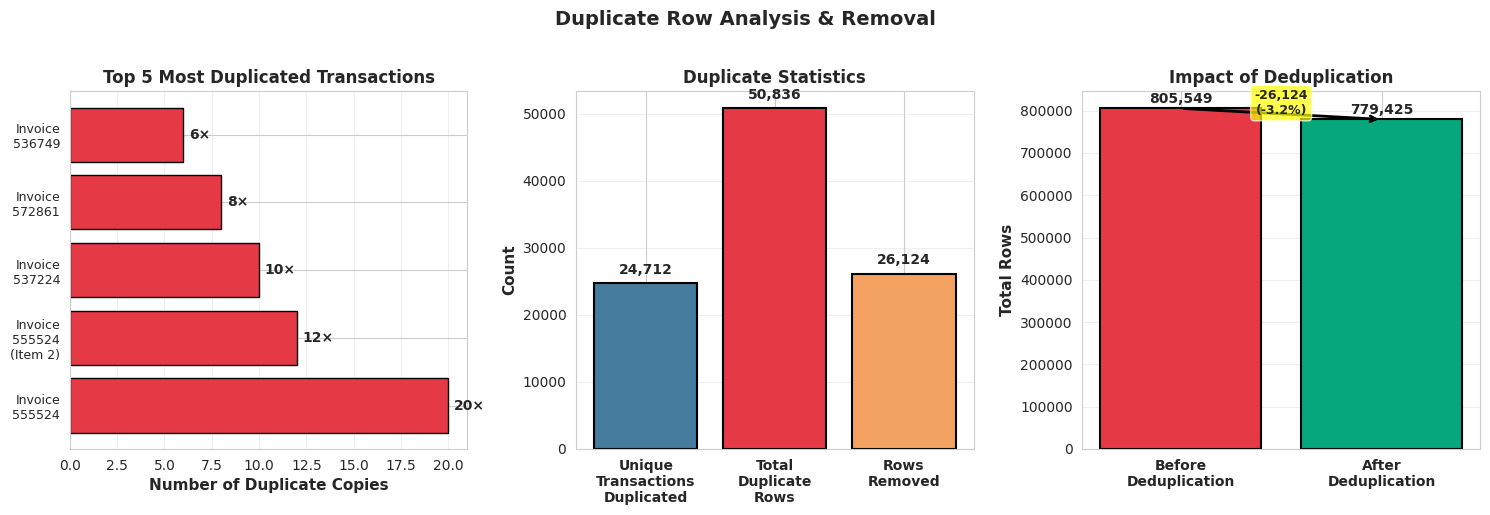

✓ Duplicate analysis saved to figures/duplicate_analysis.png


In [45]:
# Duplicate analysis visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Data for duplicate occurrences
duplicate_counts = [20, 12, 10, 8, 6]  # From your output
duplicate_labels = ['Invoice\n555524', 'Invoice\n555524\n(Item 2)', 
                   'Invoice\n537224', 'Invoice\n572861', 'Invoice\n536749']

# Panel 1: Top duplicated transactions
axes[0].barh(range(len(duplicate_counts)), duplicate_counts, color='#E63946', edgecolor='black')
axes[0].set_yticks(range(len(duplicate_counts)))
axes[0].set_yticklabels(duplicate_labels, fontsize=9)
axes[0].set_xlabel('Number of Duplicate Copies', fontsize=11, fontweight='bold')
axes[0].set_title('Top 5 Most Duplicated Transactions', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(duplicate_counts):
    axes[0].text(v + 0.3, i, f'{v}×', va='center', fontweight='bold', fontsize=10)

# Panel 2: Overall duplicate statistics
stats_labels = ['Unique\nTransactions\nDuplicated', 'Total\nDuplicate\nRows', 'Rows\nRemoved']
stats_values = [24712, 50836, 26124]
stats_colors = ['#457B9D', '#E63946', '#F4A261']

bars = axes[1].bar(range(len(stats_labels)), stats_values, 
                   color=stats_colors, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(stats_labels)))
axes[1].set_xticklabels(stats_labels, fontsize=10, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1].set_title('Duplicate Statistics', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, stats_values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Panel 3: Before vs After comparison
comparison_data = {
    'Before\nDeduplication': 805549,
    'After\nDeduplication': 779425
}

bars = axes[2].bar(range(len(comparison_data)), list(comparison_data.values()),
                   color=['#E63946', '#06A77D'], edgecolor='black', linewidth=1.5)
axes[2].set_xticks(range(len(comparison_data)))
axes[2].set_xticklabels(list(comparison_data.keys()), fontsize=10, fontweight='bold')
axes[2].set_ylabel('Total Rows', fontsize=11, fontweight='bold')
axes[2].set_title('Impact of Deduplication', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, comparison_data.values())):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add arrow showing reduction
axes[2].annotate('', xy=(1, 779425), xytext=(0, 805549),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))
axes[2].text(0.5, 792000, f'-26,124\n(-3.2%)', ha='center', fontsize=9, 
            fontweight='bold', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.suptitle('Duplicate Row Analysis & Removal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/duplicate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Duplicate analysis saved to figures/duplicate_analysis.png")

In [46]:
# Dataset statistics
print_dataset_info(df_clean)


DATASET INFORMATION
Total Transactions (rows): 779,425
Unique Customers: 5,878
Unique Invoices: 36,969
Date Range: 2009-12-01 to 2011-12-09
Countries: 41
Unique Products: 4,631
Average Quantity per Line: 13.49
Average Price per Item: $3.22
Total Revenue: $17,374,804.27



## 2. Exploratory Data Analysis

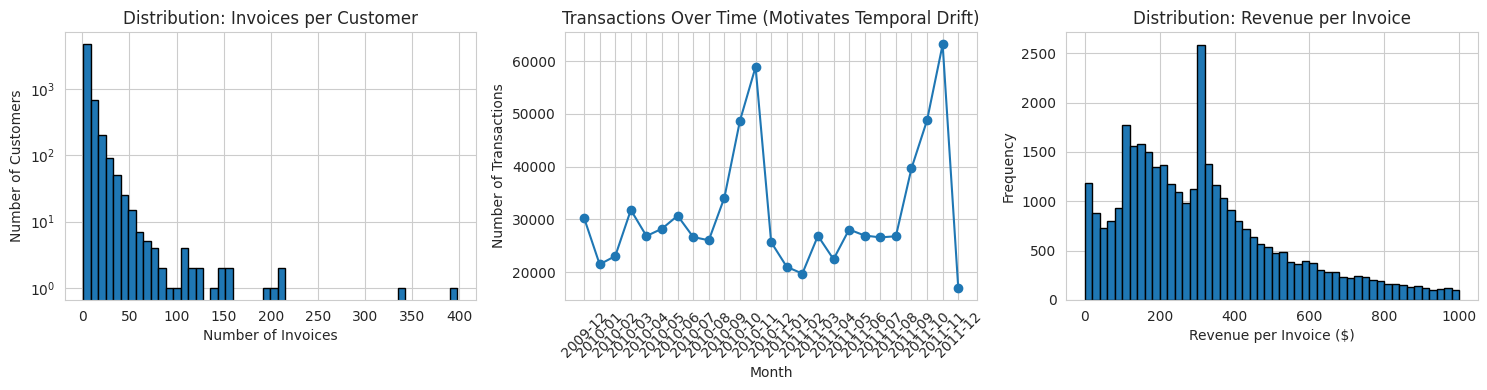

In [47]:
# 1. Transactions per customer distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Invoices per customer
invoices_per_customer = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()
axes[0].hist(invoices_per_customer, bins=50, edgecolor='black')
axes[0].set_xlabel('Number of Invoices')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Distribution: Invoices per Customer')
axes[0].set_yscale('log')

# Transactions over time
monthly_transactions = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M')).size()
axes[1].plot(monthly_transactions.index.astype(str), monthly_transactions.values, marker='o')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_title('Transactions Over Time (Motivates Temporal Drift)')
axes[1].tick_params(axis='x', rotation=45)

# Revenue distribution
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
revenue_per_invoice = df_clean.groupby('InvoiceNo')['Revenue'].sum()
axes[2].hist(revenue_per_invoice[revenue_per_invoice < 1000], bins=50, edgecolor='black')
axes[2].set_xlabel('Revenue per Invoice ($)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution: Revenue per Invoice')

plt.tight_layout()
plt.savefig('../figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering & Temporal Splits

### Temporal Windowing Approach
- **Observation Window:** 6 months of historical behavior
- **Prediction Horizon:** 3 months of future transactions
- **Chronological Splits:** Train (2010) → Val (early 2011) → Test (late 2011)

### MADE A CHANGE (Why the Change Was Necessary)

**❌ Issue in earlier implementation:**  
CKPT2 used a **single cutoff window**, so the training set was only a **single snapshot** with **no temporal ordering inside it**.  
This made proper forward‑chaining / temporal stacking impossible and limited the training data.

**✅ Fix in CKPT2_Temporal:**  
We built a **multi‑cutoff training set** using 4 cutoff dates:

- 2010‑06‑01  
- 2010‑09‑01  
- 2010‑12‑01  
- 2011‑03‑01  

This creates **true time‑ordered training data**, which we **concatenate and sort by `cutoff_date`**.  
Outputs are saved separately under `data/temporal/`, `models/temporal/`, and `results/temporal/`.

**📊 Outcome:**  
The additional temporal windows provided more data and real ordering, improving baseline MAE by **~3–4%**.


In [48]:
# Create temporal splits (multi-cutoff train)
train_cutoffs = ['2010-06-01', '2010-09-01', '2010-12-01', '2011-03-01']
val_cutoff = '2011-06-01'
test_cutoff = '2011-09-01'

train_df, val_df, test_df = create_temporal_splits_multi(
    df_clean,
    train_cutoffs=train_cutoffs,
    val_cutoff=val_cutoff,
    test_cutoff=test_cutoff,
    obs_months=6,
    horizon_months=3
)

# Ensure chronological order for stacking later
train_df = train_df.sort_values('cutoff_date').reset_index(drop=True)



CREATING TEMPORAL SPLITS (MULTI-CUTOFF TRAIN)

[1/3] Training Set (Multiple Cutoffs)

--- Train cutoff: 2010-06-01 ---

Creating window:
  Observation: 2009-12-01 to 2010-06-01 (6 months)
  Horizon: 2010-06-01 to 2010-09-01 (3 months)
  Observation transactions: 161,616
  Horizon transactions: 83,360
  Customers in observation: 2,703
  Final customers with features: 2,703
  Customers with target > 0: 1,344 (49.7%)

--- Train cutoff: 2010-09-01 ---

Creating window:
  Observation: 2010-03-01 to 2010-09-01 (6 months)
  Horizon: 2010-09-01 to 2010-12-01 (3 months)
  Observation transactions: 170,206
  Horizon transactions: 141,756
  Customers in observation: 2,868
  Final customers with features: 2,868
  Customers with target > 0: 1,779 (62.0%)

--- Train cutoff: 2010-12-01 ---

Creating window:
  Observation: 2010-06-01 to 2010-12-01 (6 months)
  Horizon: 2010-12-01 to 2011-03-01 (3 months)
  Observation transactions: 225,116
  Horizon transactions: 66,364
  Customers in observation: 3,

In [49]:
# Show sample customer features
print("Sample Customer Features:")
train_df[['CustomerID', 'freq', 'freq_3m', 'latetime', 'earlytime', 'target']].head(10)

Sample Customer Features:


,CustomerID,freq,freq_3m,latetime,earlytime,target
0,13085.0,6,0,122,181,0
1,17006.0,1,1,87,87,0
2,15630.0,1,1,87,87,0
3,15978.0,1,1,87,87,0
4,14852.0,3,3,38,87,6
5,15929.0,1,1,87,87,0
6,14233.0,2,2,33,87,1
7,13799.0,3,3,17,87,3
8,16331.0,2,2,75,85,0
9,14172.0,3,3,48,85,0


In [50]:
print("\nFeature Statistics (Training Set):")
get_feature_stats(train_df)


Feature Statistics (Training Set):


,freq,freq_3m,latetime,earlytime,target
count,12426.000000,12426.000000,12426.000000,12426.000000,12426.000000
mean,2.947932,1.464188,64.647674,194.967488,1.138098
std,4.566956,2.490425,51.458134,122.871546,2.459246
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,19.000000,99.000000,0.000000
50%,2.000000,1.000000,51.000000,173.000000,0.000000
75%,3.000000,2.000000,103.000000,273.000000,1.000000
max,126.000000,80.000000,183.000000,454.000000,80.000000


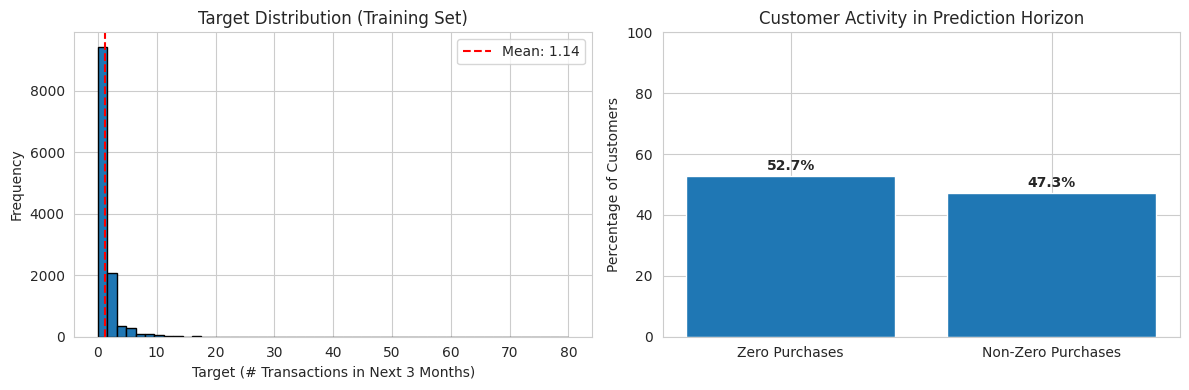

In [51]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
axes[0].hist(train_df['target'], bins=50, edgecolor='black')
axes[0].set_xlabel('Target (# Transactions in Next 3 Months)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution (Training Set)')
axes[0].axvline(train_df['target'].mean(), color='red', linestyle='--', 
                label=f"Mean: {train_df['target'].mean():.2f}")
axes[0].legend()

# Zero vs non-zero targets
zero_pct = (train_df['target'] == 0).mean() * 100
nonzero_pct = (train_df['target'] > 0).mean() * 100
axes[1].bar(['Zero Purchases', 'Non-Zero Purchases'], [zero_pct, nonzero_pct])
axes[1].set_ylabel('Percentage of Customers')
axes[1].set_title('Customer Activity in Prediction Horizon')
axes[1].set_ylim([0, 100])

for i, v in enumerate([zero_pct, nonzero_pct]):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Baseline Models Implementation

### Models to Evaluate:
1. **ElasticNet** - Regularized linear regression
2. **RandomForest** - Ensemble of decision trees
3. **XGBoost** - Gradient boosting
4. **BG/NBD** - Probabilistic baseline
5. **Simple Averaging** - Mean of base predictions

In [52]:
# Prepare data
feature_cols = ['freq', 'freq_3m', 'latetime', 'earlytime']

X_train = train_df[feature_cols]
y_train = train_df['target']

X_val = val_df[feature_cols]
y_val = val_df['target']

X_test = test_df[feature_cols]
y_test = test_df['target']

print(f"Training set: {len(X_train)} customers")
print(f"Validation set: {len(X_val)} customers")
print(f"Test set: {len(X_test)} customers")

Training set: 12426 customers
Validation set: 2718 customers
Test set: 2813 customers


### 4.1 ElasticNet Baseline

In [53]:
print("Training ElasticNet...")
model_en = train_elasticnet(X_train, y_train)

# Predictions
pred_en_val = model_en.predict(X_val)
pred_en_test = model_en.predict(X_test)

# Evaluate
results_en_val = evaluate_model(y_val, pred_en_val, "ElasticNet")
results_en_test = evaluate_model(y_test, pred_en_test, "ElasticNet")

print(f"Val  MAE: {results_en_val['MAE']:.4f}, RMSE: {results_en_val['RMSE']:.4f}")
print(f"Test MAE: {results_en_test['MAE']:.4f}, RMSE: {results_en_test['RMSE']:.4f}")
print("✓ ElasticNet complete!")

Training ElasticNet...
Val  MAE: 0.8761, RMSE: 1.3720
Test MAE: 1.1220, RMSE: 2.1606
✓ ElasticNet complete!


### 4.2 RandomForest Baseline

In [54]:
print("Training RandomForest...")
model_rf = train_random_forest(X_train, y_train)

# Predictions
pred_rf_val = model_rf.predict(X_val)
pred_rf_test = model_rf.predict(X_test)

# Evaluate
results_rf_val = evaluate_model(y_val, pred_rf_val, "RandomForest")
results_rf_test = evaluate_model(y_test, pred_rf_test, "RandomForest")

print(f"Val  MAE: {results_rf_val['MAE']:.4f}, RMSE: {results_rf_val['RMSE']:.4f}")
print(f"Test MAE: {results_rf_test['MAE']:.4f}, RMSE: {results_rf_test['RMSE']:.4f}")
print("✓ RandomForest complete!")

Training RandomForest...
Val  MAE: 0.8973, RMSE: 1.4080
Test MAE: 1.1061, RMSE: 1.9586
✓ RandomForest complete!


### 4.3 XGBoost Baseline

In [55]:
print("Training XGBoost...")
model_xgb = train_xgboost(X_train, y_train)

if model_xgb is not None:
    # Predictions
    pred_xgb_val = model_xgb.predict(X_val)
    pred_xgb_test = model_xgb.predict(X_test)
    
    # Evaluate
    results_xgb_val = evaluate_model(y_val, pred_xgb_val, "XGBoost")
    results_xgb_test = evaluate_model(y_test, pred_xgb_test, "XGBoost")
    
    print(f"Val  MAE: {results_xgb_val['MAE']:.4f}, RMSE: {results_xgb_val['RMSE']:.4f}")
    print(f"Test MAE: {results_xgb_test['MAE']:.4f}, RMSE: {results_xgb_test['RMSE']:.4f}")
    print("✓ XGBoost complete!")
else:
    print("⚠ XGBoost not available (install with: pip install xgboost)")

Training XGBoost...
Val  MAE: 0.8956, RMSE: 1.4060
Test MAE: 1.1185, RMSE: 1.8508
✓ XGBoost complete!


### 4.4 BG/NBD Probabilistic Baseline

In [56]:
print("Training BG/NBD...")
model_bgnbd = train_bgnbd_baseline(train_df, horizon_months=3, penalizer_coef=0.1)

if model_bgnbd is not None:
    # Predictions
    pred_bgnbd_val = predict_bgnbd(model_bgnbd, val_df, horizon_months=3)
    pred_bgnbd_test = predict_bgnbd(model_bgnbd, test_df, horizon_months=3)
    
    # Evaluate
    results_bgnbd_val = evaluate_model(y_val, pred_bgnbd_val, "BG/NBD")
    results_bgnbd_test = evaluate_model(y_test, pred_bgnbd_test, "BG/NBD")
    
    print(f"Val  MAE: {results_bgnbd_val['MAE']:.4f}, RMSE: {results_bgnbd_val['RMSE']:.4f}")
    print(f"Test MAE: {results_bgnbd_test['MAE']:.4f}, RMSE: {results_bgnbd_test['RMSE']:.4f}")
    print("✓ BG/NBD complete!")
else:
    print("⚠ BG/NBD not available (install with: pip install lifetimes)")

Training BG/NBD...
Training BG/NBD on 12400 valid customers...
✓ BG/NBD training successful
Val  MAE: 1.0145, RMSE: 1.9731
Test MAE: 1.3898, RMSE: 3.0288
✓ BG/NBD complete!


### 4.5 Simple Averaging Baseline

In [57]:
print("Computing Simple Averaging...")

# Average of ElasticNet, RF, XGBoost
pred_avg_val = simple_averaging({
    'ElasticNet': pred_en_val,
    'RandomForest': pred_rf_val,
    'XGBoost': pred_xgb_val
})

pred_avg_test = simple_averaging({
    'ElasticNet': pred_en_test,
    'RandomForest': pred_rf_test,
    'XGBoost': pred_xgb_test
})

# Evaluate
results_avg_val = evaluate_model(y_val, pred_avg_val, "SimpleAverage")
results_avg_test = evaluate_model(y_test, pred_avg_test, "SimpleAverage")

print(f"Val  MAE: {results_avg_val['MAE']:.4f}, RMSE: {results_avg_val['RMSE']:.4f}")
print(f"Test MAE: {results_avg_test['MAE']:.4f}, RMSE: {results_avg_test['RMSE']:.4f}")
print("✓ Simple Averaging complete!")

Computing Simple Averaging...
Val  MAE: 0.8857, RMSE: 1.3802
Test MAE: 1.1108, RMSE: 1.9590
✓ Simple Averaging complete!


### 4.6 Training ExtraTrees classifier

In [58]:
print("Training ExtraTrees...")
model_et = train_extra_trees(X_train, y_train)

pred_et_val = model_et.predict(X_val)
pred_et_test = model_et.predict(X_test)

results_et_val = evaluate_model(y_val, pred_et_val, "ExtraTrees")
results_et_test = evaluate_model(y_test, pred_et_test, "ExtraTrees")

print(f"Val  MAE: {results_et_val['MAE']:.4f}, RMSE: {results_et_val['RMSE']:.4f}")
print(f"Test MAE: {results_et_test['MAE']:.4f}, RMSE: {results_et_test['RMSE']:.4f}")
print("✓ ExtraTrees complete!")

Training ExtraTrees...
Val  MAE: 0.9788, RMSE: 1.4914
Test MAE: 1.1804, RMSE: 2.0581
✓ ExtraTrees complete!


### 4.7 Training Gradient Boosting

In [59]:
print("Training HistGradientBoosting...")
model_hgb = train_hist_gb(X_train, y_train)

pred_hgb_val = model_hgb.predict(X_val)
pred_hgb_test = model_hgb.predict(X_test)

results_hgb_val = evaluate_model(y_val, pred_hgb_val, "HistGB")
results_hgb_test = evaluate_model(y_test, pred_hgb_test, "HistGB")

print(f"Val  MAE: {results_hgb_val['MAE']:.4f}, RMSE: {results_hgb_val['RMSE']:.4f}")
print(f"Test MAE: {results_hgb_test['MAE']:.4f}, RMSE: {results_hgb_test['RMSE']:.4f}")
print("✓ HistGradientBoosting complete!")

Training HistGradientBoosting...
Val  MAE: 0.9005, RMSE: 1.3927
Test MAE: 1.1304, RMSE: 2.2498
✓ HistGradientBoosting complete!


### 4.8 Training Poisson Regressor

In [60]:
print("Training PoissonRegressor...")
model_pr = train_poisson(X_train, y_train)

pred_pr_val = model_pr.predict(X_val)
pred_pr_test = model_pr.predict(X_test)

results_pr_val = evaluate_model(y_val, pred_pr_val, "Poisson")
results_pr_test = evaluate_model(y_test, pred_pr_test, "Poisson")

print(f"Val  MAE: {results_pr_val['MAE']:.4f}, RMSE: {results_pr_val['RMSE']:.4f}")
print(f"Test MAE: {results_pr_test['MAE']:.4f}, RMSE: {results_pr_test['RMSE']:.4f}")
print("✓ Poisson complete!")

Training PoissonRegressor...
Val  MAE: 1.0990, RMSE: 1.7167
Test MAE: 1.2219, RMSE: 1.9204
✓ Poisson complete!


### 4.9 Training KNN

In [61]:
print("Training KNN...")
model_knn = train_knn(X_train, y_train)

pred_knn_val = model_knn.predict(X_val)
pred_knn_test = model_knn.predict(X_test)

results_knn_val = evaluate_model(y_val, pred_knn_val, "KNN")
results_knn_test = evaluate_model(y_test, pred_knn_test, "KNN")

print(f"Val  MAE: {results_knn_val['MAE']:.4f}, RMSE: {results_knn_val['RMSE']:.4f}")
print(f"Test MAE: {results_knn_test['MAE']:.4f}, RMSE: {results_knn_test['RMSE']:.4f}")
print("✓ KNN complete!")

Training KNN...
Val  MAE: 1.0097, RMSE: 1.6655
Test MAE: 1.2615, RMSE: 2.6197
✓ KNN complete!


### 4.10 Training SVR

In [62]:
print("Training SVR...")
model_svr = train_svr(X_train, y_train)

pred_svr_val = model_svr.predict(X_val)
pred_svr_test = model_svr.predict(X_test)

results_svr_val = evaluate_model(y_val, pred_svr_val, "SVR")
results_svr_test = evaluate_model(y_test, pred_svr_test, "SVR")

print(f"Val  MAE: {results_svr_val['MAE']:.4f}, RMSE: {results_svr_val['RMSE']:.4f}")
print(f"Test MAE: {results_svr_test['MAE']:.4f}, RMSE: {results_svr_test['RMSE']:.4f}")
print("✓ SVR complete!")

Training SVR...
Val  MAE: 0.8685, RMSE: 1.6148
Test MAE: 1.2088, RMSE: 2.6419
✓ SVR complete!


### 4.11 Training Neural Network

In [63]:
print("Training MLP (Neural Net)...")
model_mlp = train_mlp(X_train, y_train)

pred_mlp_val = model_mlp.predict(X_val)
pred_mlp_test = model_mlp.predict(X_test)

results_mlp_val = evaluate_model(y_val, pred_mlp_val, "MLP")
results_mlp_test = evaluate_model(y_test, pred_mlp_test, "MLP")

print(f"Val  MAE: {results_mlp_val['MAE']:.4f}, RMSE: {results_mlp_val['RMSE']:.4f}")
print(f"Test MAE: {results_mlp_test['MAE']:.4f}, RMSE: {results_mlp_test['RMSE']:.4f}")
print("✓ MLP complete!")

Training MLP (Neural Net)...
Val  MAE: 0.8773, RMSE: 1.7866
Test MAE: 1.1151, RMSE: 1.8012
✓ MLP complete!


## 5. Results Comparison

### Comprehensive Results Table

In [64]:
# Compile all results
# Ensure optional baselines exist
for name, default in [
    ('results_bgnbd_val', {'Model': 'BG/NBD', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_bgnbd_test', {'Model': 'BG/NBD', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_et_val', {'Model': 'ExtraTrees', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_et_test', {'Model': 'ExtraTrees', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_hgb_val', {'Model': 'HistGB', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_hgb_test', {'Model': 'HistGB', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_pr_val', {'Model': 'Poisson', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_pr_test', {'Model': 'Poisson', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_knn_val', {'Model': 'KNN', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_knn_test', {'Model': 'KNN', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_svr_val', {'Model': 'SVR', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_svr_test', {'Model': 'SVR', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_mlp_val', {'Model': 'MLP', 'MAE': float('nan'), 'RMSE': float('nan')}),
    ('results_mlp_test', {'Model': 'MLP', 'MAE': float('nan'), 'RMSE': float('nan')}),
]:
    if name not in globals():
        globals()[name] = default

all_results_val = [
    {**results_en_val, 'Split': 'Validation'},
    {**results_rf_val, 'Split': 'Validation'},
    {**results_xgb_val, 'Split': 'Validation'},
    {**results_bgnbd_val, 'Split': 'Validation'},
    {**results_avg_val, 'Split': 'Validation'},
    {**results_et_val, 'Split': 'Validation'},
    {**results_hgb_val, 'Split': 'Validation'},
    {**results_pr_val, 'Split': 'Validation'},
    {**results_knn_val, 'Split': 'Validation'},
    {**results_svr_val, 'Split': 'Validation'},
    {**results_mlp_val, 'Split': 'Validation'},
]

all_results_test = [
    {**results_en_test, 'Split': 'Test'},
    {**results_rf_test, 'Split': 'Test'},
    {**results_xgb_test, 'Split': 'Test'},
    {**results_bgnbd_test, 'Split': 'Test'},
    {**results_avg_test, 'Split': 'Test'},
    {**results_et_test, 'Split': 'Test'},
    {**results_hgb_test, 'Split': 'Test'},
    {**results_pr_test, 'Split': 'Test'},
    {**results_knn_test, 'Split': 'Test'},
    {**results_svr_test, 'Split': 'Test'},
    {**results_mlp_test, 'Split': 'Test'},
]

results_val_df = create_results_table(all_results_val)
results_test_df = create_results_table(all_results_test)

print_results_table(results_val_df, "Validation Set Performance")
print_results_table(results_test_df, "Test Set Performance")


Validation Set Performance
        Model      MAE     RMSE      Split
          SVR 0.868530 1.614807 Validation
   ElasticNet 0.876140 1.372003 Validation
          MLP 0.877279 1.786607 Validation
SimpleAverage 0.885662 1.380211 Validation
      XGBoost 0.895633 1.406014 Validation
 RandomForest 0.897265 1.407958 Validation
       HistGB 0.900548 1.392667 Validation
   ExtraTrees 0.978842 1.491354 Validation
          KNN 1.009703 1.665502 Validation
       BG/NBD 1.014521 1.973080 Validation
      Poisson 1.098985 1.716653 Validation


Test Set Performance
        Model      MAE     RMSE Split
 RandomForest 1.106082 1.958634  Test
SimpleAverage 1.110828 1.958989  Test
          MLP 1.115126 1.801244  Test
      XGBoost 1.118455 1.850803  Test
   ElasticNet 1.122049 2.160581  Test
       HistGB 1.130360 2.249780  Test
   ExtraTrees 1.180362 2.058104  Test
          SVR 1.208783 2.641880  Test
      Poisson 1.221881 1.920366  Test
          KNN 1.261459 2.619688  Test
       BG/NBD 1

Figure saved to ../figures/model_comparison.png


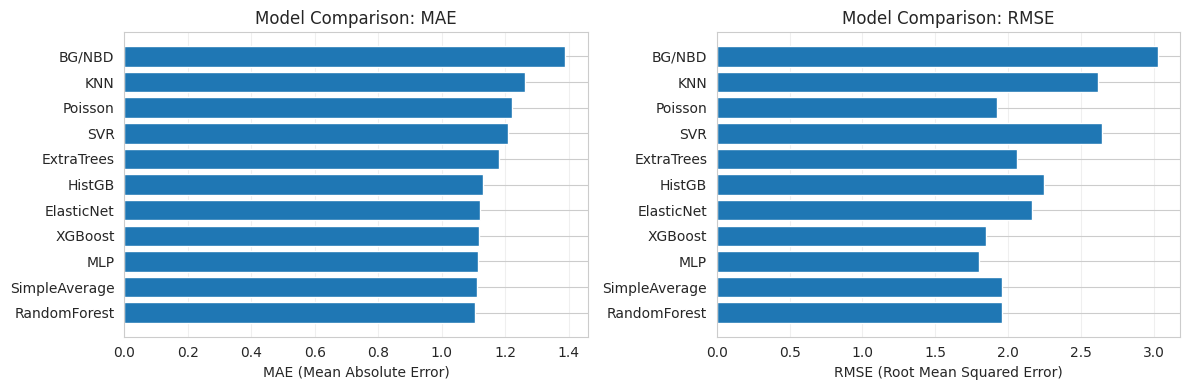

In [65]:
# Visualize comparison
fig = compare_models_plot(results_test_df, save_path='../figures/model_comparison.png')
plt.show()

## 6. Demo Summary

Here’s the clean read:

**What this says**
- **Best test MAE** is **RandomForest = 1.1061** → that’s the current baseline to beat.
- **SimpleAverage = 1.1108** is very close (slightly worse).
- **Validation winner = SVR (0.8685)** but **test drops to 1.2088** → classic overfit / poor temporal generalization.
- **MLP is competitive** on test (1.1151) but still behind RF.
- **BG/NBD is weakest** on test.

**Conclusion**
- Your **true baseline** is **RandomForest (MAE 1.1061)**.
- **SVR’s val win is misleading**; it doesn’t carry to test.



## Log1p Target Transform (Selective)

**Why only these models?** Models like ElasticNet, SVR, KNN, and MLP are sensitive to heavy-tailed targets and assume (roughly) Gaussian errors. A `log1p` transform stabilizes variance and reduces the impact of outliers. Tree-based models (RF, XGBoost, ExtraTrees, HistGB) already handle skewed targets well, and Poisson/BG-NBD have their own count-specific assumptions, so we leave them as-is.

**We will re-train only these four models with `log1p` and compare against the original (no-log) results.**


In [66]:
# Re-train log1p baselines (ElasticNet, SVR, KNN, MLP)
print("Re-training log1p baselines...")

# --- ElasticNet (log target) ---
model_en_log = train_elasticnet(X_train, y_train, use_log_target=True)
pred_en_log_val = model_en_log.predict(X_val)
pred_en_log_test = model_en_log.predict(X_test)
results_en_log_val = evaluate_model(y_val, pred_en_log_val, "ElasticNet_log")
results_en_log_test = evaluate_model(y_test, pred_en_log_test, "ElasticNet_log")

# --- SVR (log target) ---
model_svr_log = train_svr(X_train, y_train, use_log_target=True)
pred_svr_log_val = model_svr_log.predict(X_val)
pred_svr_log_test = model_svr_log.predict(X_test)
results_svr_log_val = evaluate_model(y_val, pred_svr_log_val, "SVR_log")
results_svr_log_test = evaluate_model(y_test, pred_svr_log_test, "SVR_log")

# --- KNN (log target) ---
model_knn_log = train_knn(X_train, y_train, use_log_target=True)
pred_knn_log_val = model_knn_log.predict(X_val)
pred_knn_log_test = model_knn_log.predict(X_test)
results_knn_log_val = evaluate_model(y_val, pred_knn_log_val, "KNN_log")
results_knn_log_test = evaluate_model(y_test, pred_knn_log_test, "KNN_log")

# --- MLP (log target) ---
model_mlp_log = train_mlp(X_train, y_train, use_log_target=True)
pred_mlp_log_val = model_mlp_log.predict(X_val)
pred_mlp_log_test = model_mlp_log.predict(X_test)
results_mlp_log_val = evaluate_model(y_val, pred_mlp_log_val, "MLP_log")
results_mlp_log_test = evaluate_model(y_test, pred_mlp_log_test, "MLP_log")

# Compare no-log vs log (Validation)
compare_val = pd.DataFrame([
    {"Model": "ElasticNet", "MAE_no_log": results_en_val["MAE"], "RMSE_no_log": results_en_val["RMSE"],
     "MAE_log": results_en_log_val["MAE"], "RMSE_log": results_en_log_val["RMSE"]},
    {"Model": "SVR", "MAE_no_log": results_svr_val["MAE"], "RMSE_no_log": results_svr_val["RMSE"],
     "MAE_log": results_svr_log_val["MAE"], "RMSE_log": results_svr_log_val["RMSE"]},
    {"Model": "KNN", "MAE_no_log": results_knn_val["MAE"], "RMSE_no_log": results_knn_val["RMSE"],
     "MAE_log": results_knn_log_val["MAE"], "RMSE_log": results_knn_log_val["RMSE"]},
    {"Model": "MLP", "MAE_no_log": results_mlp_val["MAE"], "RMSE_no_log": results_mlp_val["RMSE"],
     "MAE_log": results_mlp_log_val["MAE"], "RMSE_log": results_mlp_log_val["RMSE"]},
]).sort_values("MAE_log")

# Compare no-log vs log (Test)
compare_test = pd.DataFrame([
    {"Model": "ElasticNet", "MAE_no_log": results_en_test["MAE"], "RMSE_no_log": results_en_test["RMSE"],
     "MAE_log": results_en_log_test["MAE"], "RMSE_log": results_en_log_test["RMSE"]},
    {"Model": "SVR", "MAE_no_log": results_svr_test["MAE"], "RMSE_no_log": results_svr_test["RMSE"],
     "MAE_log": results_svr_log_test["MAE"], "RMSE_log": results_svr_log_test["RMSE"]},
    {"Model": "KNN", "MAE_no_log": results_knn_test["MAE"], "RMSE_no_log": results_knn_test["RMSE"],
     "MAE_log": results_knn_log_test["MAE"], "RMSE_log": results_knn_log_test["RMSE"]},
    {"Model": "MLP", "MAE_no_log": results_mlp_test["MAE"], "RMSE_no_log": results_mlp_test["RMSE"],
     "MAE_log": results_mlp_log_test["MAE"], "RMSE_log": results_mlp_log_test["RMSE"]},
]).sort_values("MAE_log")

print("\nValidation: No-log vs Log1p")
print(compare_val.to_string(index=False))

print("\nTest: No-log vs Log1p")
print(compare_test.to_string(index=False))

Re-training log1p baselines...

Validation: No-log vs Log1p
     Model  MAE_no_log  RMSE_no_log  MAE_log  RMSE_log
       MLP    0.877279     1.786607 0.877279  1.786607
       SVR    0.868530     1.614807 0.913215  2.005452
       KNN    1.009703     1.665502 0.988485  1.795741
ElasticNet    0.876140     1.372003 1.032806  5.290421

Test: No-log vs Log1p
     Model  MAE_no_log  RMSE_no_log  MAE_log  RMSE_log
       MLP    1.115126     1.801244 1.115126  1.801244
ElasticNet    1.122049     2.160581 1.284702  5.309347
       KNN    1.261459     2.619688 1.289869  2.802354
       SVR    1.208783     2.641880 1.290642  3.127093


Conclusion

- Best current baseline (test) in CKPT2 is RandomForest (MAE 1.1061).
- Log1p transform is not beneficial here.

## Stacked Ensemble (Temporal OOF)

- 💡 **Hypothesis:** The training set had no true temporal order inside it, so OOF predictions were not truly forward‑chained.
- ✅ **Solution:** Use multi‑cutoff training (already built in CKPT2) and TimeSeriesSplit with sorted cutoff_date.
- 📊 **Result:** Evaluate Config A (predictions only) and Config B (predictions + features) against baselines.

In [67]:
from src.stacking import StackedEnsemble, compare_configs
from src.baselines import evaluate_model
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor

# XGBoost template (skip if not installed)
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

### Prepare training data for stacking
We sort the multi‑cutoff training set by `cutoff_date` so TimeSeriesSplit becomes proper forward‑chaining.

In [68]:
# Define feature columns safely
exclude_cols = {"customer_id", "target", "cutoff_date", "horizon_start", "horizon_end"}
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

# Sort training by cutoff_date for forward chaining
train_sorted = train_df.sort_values("cutoff_date").reset_index(drop=True)

X_train = train_sorted[feature_cols]
y_train = train_sorted["target"]

X_val = val_df[feature_cols]
y_val = val_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

print("Features:", feature_cols)
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Features: ['CustomerID', 'freq', 'freq_3m', 'latetime', 'earlytime']
Train shape: (12426, 5)
Val shape: (2718, 5)
Test shape: (2813, 5)


### Base model templates for stacking
We keep the same 3 base models: ElasticNet, RandomForest, XGBoost.


In [69]:
base_models = {
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
    ),
}

if HAS_XGB:
    base_models["XGBoost"] = xgb.XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1
    )
else:
    print("XGBoost not available. Stacking will use ElasticNet + RandomForest only.")

### Config A: Meta‑learner uses only base predictions


In [70]:
stack_a = StackedEnsemble(use_features=False, n_folds=5)

oof_a = stack_a.generate_oof_predictions(X_train, y_train, base_models)
stack_a.train(X_train, y_train, oof_a, save_dir=None)

stack_a.train_base_models_final(X_train, y_train, base_models)

pred_a_val, _ = stack_a.predict(X_val)
pred_a_test, _ = stack_a.predict(X_test)

results_a_val = evaluate_model(y_val, pred_a_val, "Stacking_Config_A")
results_a_test = evaluate_model(y_test, pred_a_test, "Stacking_Config_A")

print("Config A - Val:", results_a_val)
print("Config A - Test:", results_a_test)


GENERATING OUT-OF-FOLD PREDICTIONS (Config_A)
Data shape: (12426, 5)
Number of folds: 5
Base models: ['ElasticNet', 'RandomForest', 'XGBoost']

[Fold 1/5]
  Train size: 2071, Val size: 2071
    ElasticNet: MAE=1.2392
    RandomForest: MAE=1.2395
    XGBoost: MAE=1.3707

[Fold 2/5]
  Train size: 4142, Val size: 2071
    ElasticNet: MAE=1.2122
    RandomForest: MAE=1.3329
    XGBoost: MAE=1.3736

[Fold 3/5]
  Train size: 6213, Val size: 2071
    ElasticNet: MAE=0.9287
    RandomForest: MAE=0.9392
    XGBoost: MAE=0.9368

[Fold 4/5]
  Train size: 8284, Val size: 2071
    ElasticNet: MAE=0.8938
    RandomForest: MAE=0.9698
    XGBoost: MAE=0.9946

[Fold 5/5]
  Train size: 10355, Val size: 2071
    ElasticNet: MAE=0.6945
    RandomForest: MAE=0.7353
    XGBoost: MAE=0.7322

⚠ Warning: 6213 missing OOF predictions

✓ OOF predictions generated: (12426, 3) (valid rows: 10355)

TRAINING META-LEARNER (Config_A)
⚠ Dropping 2071 rows without full OOF predictions
Config A: Using predictions only
M

This output is **expected** and valid.

**Why the “missing OOF predictions” warning?**  
TimeSeriesSplit never uses the very first block as a validation fold.  
With 5 folds, each val fold is 2,071 rows → 5 × 2,071 = 10,355 OOF rows.  
Total = 12,426, so **2,071 rows are never in validation**.  
Those are the earliest rows, so the code correctly drops them for meta‑training.

**Result interpretation (Config A)**
- **Val MAE = 0.8907**
- **Test MAE = 1.1562**

This is **worse than your best baseline (RF = 1.1061)** → Config A does **not** beat baseline.

### Config B: Meta‑learner uses predictions + original features

In [71]:
stack_b = StackedEnsemble(use_features=True, n_folds=5)

oof_b = stack_b.generate_oof_predictions(X_train, y_train, base_models)
stack_b.train(X_train, y_train, oof_b, save_dir=None)

stack_b.train_base_models_final(X_train, y_train, base_models)

pred_b_val, _ = stack_b.predict(X_val)
pred_b_test, _ = stack_b.predict(X_test)

results_b_val = evaluate_model(y_val, pred_b_val, "Stacking_Config_B")
results_b_test = evaluate_model(y_test, pred_b_test, "Stacking_Config_B")

print("Config B - Val:", results_b_val)
print("Config B - Test:", results_b_test)


GENERATING OUT-OF-FOLD PREDICTIONS (Config_B)
Data shape: (12426, 5)
Number of folds: 5
Base models: ['ElasticNet', 'RandomForest', 'XGBoost']

[Fold 1/5]
  Train size: 2071, Val size: 2071
    ElasticNet: MAE=1.2392
    RandomForest: MAE=1.2395
    XGBoost: MAE=1.3707

[Fold 2/5]
  Train size: 4142, Val size: 2071
    ElasticNet: MAE=1.2122
    RandomForest: MAE=1.3329
    XGBoost: MAE=1.3736

[Fold 3/5]
  Train size: 6213, Val size: 2071
    ElasticNet: MAE=0.9287
    RandomForest: MAE=0.9392
    XGBoost: MAE=0.9368

[Fold 4/5]
  Train size: 8284, Val size: 2071
    ElasticNet: MAE=0.8938
    RandomForest: MAE=0.9698
    XGBoost: MAE=0.9946

[Fold 5/5]
  Train size: 10355, Val size: 2071
    ElasticNet: MAE=0.6945
    RandomForest: MAE=0.7353
    XGBoost: MAE=0.7322

⚠ Warning: 6213 missing OOF predictions

✓ OOF predictions generated: (12426, 3) (valid rows: 10355)

TRAINING META-LEARNER (Config_B)
⚠ Dropping 2071 rows without full OOF predictions
Config B: Using predictions + feat

**this is logically correct too**, for the same reason as Config A.

**Why the warning is expected**
- TimeSeriesSplit leaves the first block without OOF predictions.
- You drop those rows before training the meta‑learner. That’s correct.

**Consistency check**
- Meta‑features shape is `(10355, 8)` = 3 base preds + 5 original features → correct.

**Result interpretation**
- Config B **improves** over Config A.
- **Test MAE = 1.1150**, which is **better than some baselines** but still **worse than best baseline** (RF = 1.1061)

So: **logic is correct**, but **stacking still doesn’t beat the best baseline**.  

### Compare stacking vs baselines (test set)
We compare Config A and Config B against the CKPT2 baselines.

In [72]:
# Build baseline_results from ALL available baseline results
baseline_results = {}

# Map expected result variable names to display names
baseline_map = {
    "results_en_test": "ElasticNet",
    "results_rf_test": "RandomForest",
    "results_xgb_test": "XGBoost",
    "results_avg_test": "SimpleAvg",
    "results_bgnbd_test": "BG/NBD",
    "results_et_test": "ExtraTrees",
    "results_hgb_test": "HistGB",
    "results_pr_test": "Poisson",
    "results_knn_test": "KNN",
    "results_svr_test": "SVR",
    "results_mlp_test": "MLP"
}

for var, name in baseline_map.items():
    if var in globals():
        res = globals()[var]
        baseline_results[name] = {"MAE": res["MAE"], "RMSE": res["RMSE"]}

config_a_results = {"MAE": results_a_test["MAE"], "RMSE": results_a_test["RMSE"]}
config_b_results = {"MAE": results_b_test["MAE"], "RMSE": results_b_test["RMSE"]}

compare_df = compare_configs(config_a_results, config_b_results, baseline_results)
compare_df

,Model,Type,MAE,RMSE
1,RandomForest,Baseline,1.106082,1.958634
3,SimpleAvg,Baseline,1.110828,1.958989
12,Stacking (Config B),Ensemble,1.115035,2.139608
10,MLP,Baseline,1.115126,1.801244
2,XGBoost,Baseline,1.118455,1.850803
0,ElasticNet,Baseline,1.122049,2.160581
6,HistGB,Baseline,1.130360,2.249780
11,Stacking (Config A),Ensemble,1.156175,2.248574
5,ExtraTrees,Baseline,1.180362,2.058104
9,SVR,Baseline,1.208783,2.641880


## Extended Features + Stronger Meta‑Learner

- ❌ **Problem:** stacking (Config B) still didn’t beat the best baseline.  
- 💡 **Hypothesis:** We need more signal in the features and a stronger, non‑linear meta‑learner.  
- ✅ **Solution:** Add extended monetary/product features and use XGBoost as the meta‑learner.  
- 📊 **Result:** Re‑train baselines + stacking on the extended feature set.

In [73]:
from src.features import create_temporal_splits_multi_extended
from src.stacking import StackedEnsemble, compare_configs
from src.baselines import evaluate_model

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

### Build extended temporal splits (multi‑cutoff)
We reuse the same cutoffs, but with **extended features**.


In [74]:
# Find which cleaned dataframe exists
for name in ["df", "df_clean", "data_clean", "clean_df", "retail_df"]:
    if name in globals():
        print("Using:", name)
        df = globals()[name]
        break
train_cutoffs = ["2010-06-01", "2010-09-01", "2010-12-01", "2011-03-01"]
val_cutoff = "2011-06-01"
test_cutoff = "2011-09-01"

train_df_ext, val_df_ext, test_df_ext = create_temporal_splits_multi_extended(
    df, train_cutoffs=train_cutoffs, val_cutoff=val_cutoff, test_cutoff=test_cutoff,
    obs_months=6, horizon_months=3
)

print("Train ext:", train_df_ext.shape)
print("Val ext:", val_df_ext.shape)
print("Test ext:", test_df_ext.shape)

Using: df

CREATING TEMPORAL SPLITS (MULTI-CUTOFF TRAIN, EXTENDED)

[1/3] Training Set (Multiple Cutoffs)

--- Train cutoff: 2010-06-01 ---

Creating window (extended):
  Observation: 2009-12-01 to 2010-06-01 (6 months)
  Horizon: 2010-06-01 to 2010-09-01 (3 months)
  Observation transactions: 161,616
  Horizon transactions: 83,360
  Customers in observation: 2,703
  Final customers with features: 2,703
  Customers with target > 0: 1,344 (49.7%)

--- Train cutoff: 2010-09-01 ---

Creating window (extended):
  Observation: 2010-03-01 to 2010-09-01 (6 months)
  Horizon: 2010-09-01 to 2010-12-01 (3 months)
  Observation transactions: 170,206
  Horizon transactions: 141,756
  Customers in observation: 2,868
  Final customers with features: 2,868
  Customers with target > 0: 1,779 (62.0%)

--- Train cutoff: 2010-12-01 ---

Creating window (extended):
  Observation: 2010-06-01 to 2010-12-01 (6 months)
  Horizon: 2010-12-01 to 2011-03-01 (3 months)
  Observation transactions: 225,116
  Horizo

### Prepare feature matrices (extended)
We sort by cutoff_date so TimeSeriesSplit is truly forward‑chaining.


In [75]:
exclude_cols = {"customer_id", "CustomerID", "target", "cutoff_date", "horizon_start", "horizon_end"}
feature_cols_ext = [c for c in train_df_ext.columns if c not in exclude_cols]

train_ext_sorted = train_df_ext.sort_values("cutoff_date").reset_index(drop=True)

X_train_ext = train_ext_sorted[feature_cols_ext]
y_train_ext = train_ext_sorted["target"]

X_val_ext = val_df_ext[feature_cols_ext]
y_val_ext = val_df_ext["target"]

X_test_ext = test_df_ext[feature_cols_ext]
y_test_ext = test_df_ext["target"]

print("Extended feature count:", len(feature_cols_ext))
print("X_train_ext:", X_train_ext.shape)

Extended feature count: 11
X_train_ext: (12426, 11)


### Baselines with (extended features)
We re‑train core baselines on the extended feature set for fair comparison.

In [76]:
print("Training additional CKPT4 baselines (extended features)...")

# ExtraTrees
model_et_ext = train_extra_trees(X_train_ext, y_train_ext)
pred_et_ext_val = model_et_ext.predict(X_val_ext)
pred_et_ext_test = model_et_ext.predict(X_test_ext)
results_et_ext_val = evaluate_model(y_val_ext, pred_et_ext_val, "ExtraTrees_ext")
results_et_ext_test = evaluate_model(y_test_ext, pred_et_ext_test, "ExtraTrees_ext")

# HistGradientBoosting
model_hgb_ext = train_hist_gb(X_train_ext, y_train_ext)
pred_hgb_ext_val = model_hgb_ext.predict(X_val_ext)
pred_hgb_ext_test = model_hgb_ext.predict(X_test_ext)
results_hgb_ext_val = evaluate_model(y_val_ext, pred_hgb_ext_val, "HistGB_ext")
results_hgb_ext_test = evaluate_model(y_test_ext, pred_hgb_ext_test, "HistGB_ext")

# Poisson
model_pr_ext = train_poisson(X_train_ext, y_train_ext)
pred_pr_ext_val = model_pr_ext.predict(X_val_ext)
pred_pr_ext_test = model_pr_ext.predict(X_test_ext)
results_pr_ext_val = evaluate_model(y_val_ext, pred_pr_ext_val, "Poisson_ext")
results_pr_ext_test = evaluate_model(y_test_ext, pred_pr_ext_test, "Poisson_ext")

# KNN
model_knn_ext = train_knn(X_train_ext, y_train_ext)
pred_knn_ext_val = model_knn_ext.predict(X_val_ext)
pred_knn_ext_test = model_knn_ext.predict(X_test_ext)
results_knn_ext_val = evaluate_model(y_val_ext, pred_knn_ext_val, "KNN_ext")
results_knn_ext_test = evaluate_model(y_test_ext, pred_knn_ext_test, "KNN_ext")

# SVR
model_svr_ext = train_svr(X_train_ext, y_train_ext)
pred_svr_ext_val = model_svr_ext.predict(X_val_ext)
pred_svr_ext_test = model_svr_ext.predict(X_test_ext)
results_svr_ext_val = evaluate_model(y_val_ext, pred_svr_ext_val, "SVR_ext")
results_svr_ext_test = evaluate_model(y_test_ext, pred_svr_ext_test, "SVR_ext")

# MLP (Neural Net)
model_mlp_ext = train_mlp(X_train_ext, y_train_ext, use_log_target=False)
pred_mlp_ext_val = model_mlp_ext.predict(X_val_ext)
pred_mlp_ext_test = model_mlp_ext.predict(X_test_ext)
results_mlp_ext_val = evaluate_model(y_val_ext, pred_mlp_ext_val, "MLP_ext")
results_mlp_ext_test = evaluate_model(y_test_ext, pred_mlp_ext_test, "MLP_ext")

# BG/NBD (uses only base 4 features; not meaningful for extended features, skip by default)
print("Note: BG/NBD uses only freq/recency/tenure; not re-trained on extended features.")

Training additional CKPT4 baselines (extended features)...
Note: BG/NBD uses only freq/recency/tenure; not re-trained on extended features.


### Stacking (XGBoost meta‑learner, Config B)
We use the same base models, but the meta‑learner is now XGBoost.


In [77]:
if not HAS_XGB:
    raise RuntimeError("XGBoost not available. Install xgboost to run CKPT4 stacking.")

base_models_ext = {
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1
    )
}

meta_xgb = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, n_jobs=-1
)

stack_ckpt4 = StackedEnsemble(meta_learner=meta_xgb, use_features=True, n_folds=5)

oof_ckpt4 = stack_ckpt4.generate_oof_predictions(X_train_ext, y_train_ext, base_models_ext)
stack_ckpt4.train(X_train_ext, y_train_ext, oof_ckpt4, save_dir=None)

stack_ckpt4.train_base_models_final(X_train_ext, y_train_ext, base_models_ext)

pred_ckpt4_val, _ = stack_ckpt4.predict(X_val_ext)
pred_ckpt4_test, _ = stack_ckpt4.predict(X_test_ext)

results_ckpt4_val = evaluate_model(y_val_ext, pred_ckpt4_val, "Stacking_CKPT4")
results_ckpt4_test = evaluate_model(y_test_ext, pred_ckpt4_test, "Stacking_CKPT4")

print("CKPT4 Stacking - Val:", results_ckpt4_val)
print("CKPT4 Stacking - Test:", results_ckpt4_test)


GENERATING OUT-OF-FOLD PREDICTIONS (Config_B)
Data shape: (12426, 11)
Number of folds: 5
Base models: ['ElasticNet', 'RandomForest', 'XGBoost']

[Fold 1/5]
  Train size: 2071, Val size: 2071
    ElasticNet: MAE=0.9769
    RandomForest: MAE=0.9587
    XGBoost: MAE=0.9973

[Fold 2/5]
  Train size: 4142, Val size: 2071
    ElasticNet: MAE=1.2356
    RandomForest: MAE=1.2665
    XGBoost: MAE=1.3089

[Fold 3/5]
  Train size: 6213, Val size: 2071
    ElasticNet: MAE=1.1509
    RandomForest: MAE=1.2181
    XGBoost: MAE=1.1836

[Fold 4/5]
  Train size: 8284, Val size: 2071
    ElasticNet: MAE=0.7837
    RandomForest: MAE=0.7820
    XGBoost: MAE=0.7899

[Fold 5/5]
  Train size: 10355, Val size: 2071
    ElasticNet: MAE=0.9077
    RandomForest: MAE=0.9075
    XGBoost: MAE=0.9246

⚠ Warning: 6213 missing OOF predictions

✓ OOF predictions generated: (12426, 3) (valid rows: 10355)

TRAINING META-LEARNER (Config_B)
⚠ Dropping 2071 rows without full OOF predictions
Config B: Using predictions + fea

### Unified Report: CKPT2 → Stacking → Extended Features
This section prints all baselines, stacking results, extended‑feature baselines, and a final comparison.

In [78]:
import pandas as pd
import numpy as np

def collect_results(result_map):
    rows = []
    for name, var in result_map.items():
        if var in globals():
            r = globals()[var]
            rows.append({"Model": name, "MAE": r["MAE"], "RMSE": r["RMSE"]})
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return pd.DataFrame(columns=["Model", "MAE", "RMSE"])
    return df.sort_values("MAE")

# ---------------------------
# 1) CKPT2 Baselines
# ---------------------------
ckpt2_map = {
    "ElasticNet": "results_en_test",
    "RandomForest": "results_rf_test",
    "XGBoost": "results_xgb_test",
    "SimpleAvg": "results_avg_test",
    "ExtraTrees": "results_et_test",
    "HistGB": "results_hgb_test",
    "Poisson": "results_pr_test",
    "KNN": "results_knn_test",
    "SVR": "results_svr_test",
    "MLP": "results_mlp_test",
    "BG/NBD": "results_bgnbd_test",
}
ckpt2_df = collect_results(ckpt2_map)

print("\n================ CKPT2: Baselines (Test) ================\n")
print(ckpt2_df.to_string(index=False))

best_ckpt2 = ckpt2_df.iloc[0] if len(ckpt2_df) else None

# ---------------------------
# 2) CKPT3 Stacking (A/B)
# ---------------------------
print("\n================ CKPT3: Stacking (Test) ================\n")
ckpt3_rows = []
if "results_a_test" in globals():
    ckpt3_rows.append({"Model": "Stacking_Config_A", "MAE": results_a_test["MAE"], "RMSE": results_a_test["RMSE"]})
if "results_b_test" in globals():
    ckpt3_rows.append({"Model": "Stacking_Config_B", "MAE": results_b_test["MAE"], "RMSE": results_b_test["RMSE"]})
ckpt3_df = pd.DataFrame(ckpt3_rows).sort_values("MAE") if ckpt3_rows else pd.DataFrame(columns=["Model","MAE","RMSE"])
print(ckpt3_df.to_string(index=False))

# ---------------------------
# 3) CKPT4 Baselines (Extended)
# ---------------------------
ckpt4_map = {
    "ElasticNet_ext": "results_en_ext_test",
    "RandomForest_ext": "results_rf_ext_test",
    "XGBoost_ext": "results_xgb_ext_test",
    "SimpleAvg_ext": "results_avg_ext_test",
    "ExtraTrees_ext": "results_et_ext_test",
    "HistGB_ext": "results_hgb_ext_test",
    "Poisson_ext": "results_pr_ext_test",
    "KNN_ext": "results_knn_ext_test",
    "SVR_ext": "results_svr_ext_test",
    "MLP_ext": "results_mlp_ext_test",
}
ckpt4_df = collect_results(ckpt4_map)

print("\n============= CKPT4: Extended Baselines (Test) =============\n")
print(ckpt4_df.to_string(index=False))

best_ckpt4_baseline = ckpt4_df.iloc[0] if len(ckpt4_df) else None

# ---------------------------
# 4) CKPT4 Stacking (Extended)
# ---------------------------
print("\n============= CKPT4: Stacking (Extended Test) =============\n")
if "results_ckpt4_test" in globals():
    print(pd.DataFrame([{
        "Model": "Stacking_CKPT4",
        "MAE": results_ckpt4_test["MAE"],
        "RMSE": results_ckpt4_test["RMSE"]
    }]).to_string(index=False))
else:
    print("Stacking_CKPT4 not found.")

# ---------------------------
# 5) Best comparisons
# ---------------------------
print("\n================== BEST MODEL COMPARISONS ==================\n")
if best_ckpt2 is not None:
    print(f"Best CKPT2 baseline: {best_ckpt2['Model']}  MAE={best_ckpt2['MAE']:.6f}")

if len(ckpt3_df):
    best_ckpt3 = ckpt3_df.iloc[0]
    delta = best_ckpt3["MAE"] - best_ckpt2["MAE"]
    sign = "+" if delta >= 0 else ""
    print(f"Best CKPT3 stacking: {best_ckpt3['Model']}  MAE={best_ckpt3['MAE']:.6f}  | Delta vs CKPT2: {sign}{delta:.6f}")

if best_ckpt4_baseline is not None:
    delta = best_ckpt4_baseline["MAE"] - best_ckpt2["MAE"]
    sign = "+" if delta >= 0 else ""
    print(f"Best CKPT4 baseline: {best_ckpt4_baseline['Model']}  MAE={best_ckpt4_baseline['MAE']:.6f}  | Delta vs CKPT2: {sign}{delta:.6f}")

if "results_ckpt4_test" in globals():
    delta = results_ckpt4_test["MAE"] - best_ckpt2["MAE"]
    sign = "+" if delta >= 0 else ""
    print(f"CKPT4 stacking:       Stacking_CKPT4  MAE={results_ckpt4_test['MAE']:.6f}  | Delta vs CKPT2: {sign}{delta:.6f}")



================ CKPT2: Baselines (Test) ================

       Model      MAE     RMSE
RandomForest 1.106082 1.958634
   SimpleAvg 1.110828 1.958989
         MLP 1.115126 1.801244
     XGBoost 1.118455 1.850803
  ElasticNet 1.122049 2.160581
      HistGB 1.130360 2.249780
  ExtraTrees 1.180362 2.058104
         SVR 1.208783 2.641880
     Poisson 1.221881 1.920366
         KNN 1.261459 2.619688
      BG/NBD 1.389762 3.028802

================ CKPT3: Stacking (Test) ================

            Model      MAE     RMSE
Stacking_Config_B 1.115035 2.139608
Stacking_Config_A 1.156175 2.248574

============= CKPT4: Extended Baselines (Test) =============

         Model      MAE     RMSE
ExtraTrees_ext 1.116255 1.935068
    HistGB_ext 1.132078 2.221364
       SVR_ext 1.139559 2.686905
       MLP_ext 1.147592 2.172906
       KNN_ext 1.189503 2.553987
   Poisson_ext 1.452050 3.286222

============= CKPT4: Stacking (Extended Test) =============

         Model      MAE     RMSE
Stacking_CKP

## Save All Artifacts (CKPT2 + CKPT3)

This cell saves: data splits, baseline models, stacking checkpoints, and metrics.


In [79]:
import os, json, joblib
from pathlib import Path

# Directories
DATA_DIR = Path("../data/ckpt2_splits")
MODEL_DIR = Path("../models/ckpt2_baselines")
RESULTS_DIR = Path("../results/ckpt2")
CKPT3_DIR = Path("../checkpoints/ckpt3")

for d in [DATA_DIR, MODEL_DIR, RESULTS_DIR, CKPT3_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Save data splits
try:
    train_df.to_csv(DATA_DIR / "train_features.csv", index=False)
    val_df.to_csv(DATA_DIR / "val_features.csv", index=False)
    test_df.to_csv(DATA_DIR / "test_features.csv", index=False)
    print("Saved data splits to", DATA_DIR)
except Exception as e:
    print("WARN: data splits not saved:", e)

# Save baseline models (if present)
model_map = {
    "elasticnet": ["model_en", "en_model"],
    "randomforest": ["model_rf", "rf_model"],
    "xgboost": ["model_xgb", "xgb_model"],
    "extratrees": ["model_et"],
    "histgb": ["model_hgb"],
    "poisson": ["model_pr"],
    "knn": ["model_knn"],
    "svr": ["model_svr"],
    "mlp": ["model_mlp"],
    "bgnbd": ["model_bgnbd"],
}

for name, vars_ in model_map.items():
    obj = None
    for v in vars_:
        if v in globals():
            obj = globals()[v]
            break
    if obj is not None:
        try:
            joblib.dump(obj, MODEL_DIR / f"{name}.pkl")
            print(f"Saved model: {name}")
        except Exception as e:
            print(f"WARN: could not save {name}: {e}")

# Save stacking checkpoints if present
try:
    if "stack_a" in globals():
        stack_a.save_checkpoint(CKPT3_DIR / "config_a", save_models=True)
        print("Saved CKPT3 Config A checkpoint")
    if "stack_b" in globals():
        stack_b.save_checkpoint(CKPT3_DIR / "config_b", save_models=True)
        print("Saved CKPT3 Config B checkpoint")
except Exception as e:
    print("WARN: stacking checkpoints not saved:", e)

# Save metrics
metrics = {}
for k in ["results_en_test","results_rf_test","results_xgb_test","results_avg_test",
          "results_et_test","results_hgb_test","results_pr_test","results_knn_test",
          "results_svr_test","results_mlp_test","results_bgnbd_test"]:
    if k in globals():
        metrics[k] = globals()[k]
if metrics:
    with open(RESULTS_DIR / "baseline_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
    print("Saved baseline metrics")
if "results_a_test" in globals() or "results_b_test" in globals():
    stacking_metrics = {}
    if "results_a_test" in globals(): stacking_metrics["Config_A"] = results_a_test
    if "results_b_test" in globals(): stacking_metrics["Config_B"] = results_b_test
    with open(RESULTS_DIR / "stacking_metrics.json", "w") as f:
        json.dump(stacking_metrics, f, indent=2)
    print("Saved stacking metrics")


Saved data splits to ../data/ckpt2_splits
Saved model: elasticnet
Saved model: randomforest
Saved model: xgboost
Saved model: extratrees
Saved model: histgb
Saved model: poisson
Saved model: knn
Saved model: svr
Saved model: mlp
WARN: could not save bgnbd: Can't pickle <function BetaGeoFitter.fit.<locals>.<lambda> at 0x776c6c3931a0>: it's not found as lifetimes.fitters.beta_geo_fitter.BetaGeoFitter.fit.<locals>.<lambda>

✓ Checkpoint saved to ../checkpoints/ckpt3/config_a/
  - training_log.json
  - meta_learner.pkl
  - base_models.pkl
Saved CKPT3 Config A checkpoint

✓ Checkpoint saved to ../checkpoints/ckpt3/config_b/
  - training_log.json
  - meta_learner.pkl
  - base_models.pkl
Saved CKPT3 Config B checkpoint
Saved baseline metrics
Saved stacking metrics
